In [ ]:
#Now takes in any 3D point, and can predict where 
#that point should go based on the vector field

import torch
import numpy as np
import torch.nn as nn
from FlowMatching import Flow
from tqdm import tqdm
import torch.optim as optim
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

flow = Flow()
mixture_prob = np.array([0.55, 0.45], dtype=float)
mixture_mus = np.array([[-0.85, 0.3, -1.0], [1.5, -0.5, 0.8]], dtype=float)  
mixture_sigmas = np.array([[0.65, 0.5, 0.4], [0.25, 0.3, 0.35]], dtype=float) 


def interp(x0, x1, t):
    xt = ((1-t) * x0) + (t * x1)
    return xt
def targVel(x0, x1):
    return x1 - x0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def computeLoss(model, x1, condition):
        batch_size = x1.shape[0]
        t = torch.rand(batch_size, 1, device=x1.device)
        x0 = torch.randn_like(x1, device=x1.device)
        xt = interp(x0, x1, t)
        vTarg = targVel(x0, x1)
        vPred = model(t, xt, condition)
        loss = torch.mean((vPred - vTarg) ** 2)
        return loss

def generateTraining(batch_size = 64, p_condition = 0.55):
     conditions = np.random.choice([0, 1], size=batch_size, p = [p_condition, 1.0-p_condition])
     means = mixture_mus[conditions]
     stds = mixture_sigmas[conditions]
     x1 = np.random.normal(loc=means, scale=stds)
     return conditions, x1



def mixture_sample(condition):
     if condition in (0, 1):
          return np.random.normal(loc=mixture_mus[condition], scale=mixture_sigmas[condition])
     else:
          raise ValueError("Condition must be 0 or 1")


def display_figure(fig, *, altText):
     display(fig, metadata = {"alt": altText})
     plt.close(fig)


In [5]:
class FlowMatchingModel(nn.Module):
    def __init__(self, data_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(data_dim + 2, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, data_dim),)

    def forward(self, t, x_t, condition):
        txc = torch.cat([t, x_t, condition], dim=-1)
        return self.net(txc)

In [ ]:
#dDim is now 3 to represent the third dimension of data for us: (x, y, z)
dDim = 3
hiddenDim = 64
trainIters = 10000
lr = 1e-3
batchSize = 256
np.random.seed(42)
torch.manual_seed(626)
model = FlowMatchingModel(dDim, hiddenDim).to(DEVICE).train()
optimizer = optim.Adam(model.parameters(), lr)
losses = []
with tqdm(range(trainIters), desc="Training", unit="iteration") as progress_bar:
    for i in progress_bar:
        conds, x1np = generateTraining(batch_size = batchSize)
        x1 = torch.tensor(x1np, dtype=torch.float32, device=DEVICE)
        conditions = torch.tensor(conds, dtype=torch.float32, device=DEVICE).unsqueeze(-1)
        loss = computeLoss(model, x1, conditions)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        progress_bar.set_postfix({"Loss": f"{loss.item():.2f}"})

Training: 100%|██████████| 10000/10000 [00:31<00:00, 317.52iteration/s, Loss=0.61]


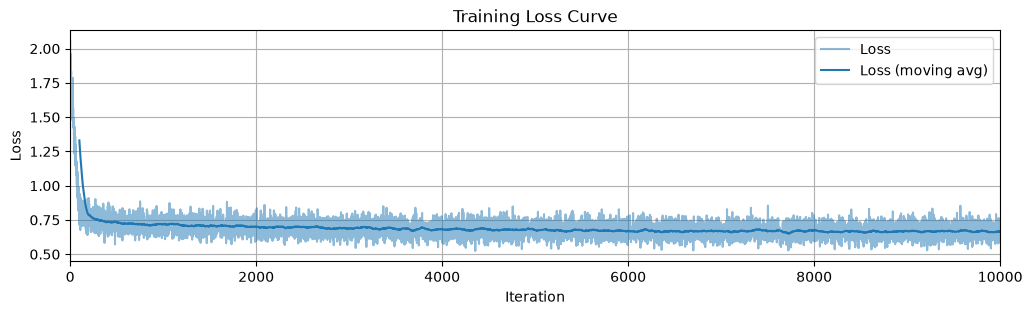

In [ ]:
#Very normal loss plot, showing a slow, asymptotic decrease 
#in the loss over many iterations, which makes sense
fig, ax = plt.subplots(figsize=(12, 3), dpi=100)
ax.plot(losses, color="tab:blue", alpha=0.5, label="Loss")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Curve")
# Plot a smoothed loss curve using a simple moving average
window_size = 100
smoothed_losses = np.convolve(losses, np.ones(window_size) / window_size, mode="valid")
ax.plot(np.arange(window_size - 1, len(losses)), smoothed_losses, color="tab:blue", label="Loss (moving avg)")
ax.legend(loc="upper right")
ax.set_xlim(0, len(losses))
ax.grid(True)
display_figure(
    fig,
    altText="Training loss over optimization steps.",
)
del fig, ax, window_size, smoothed_losses

condition 0 -- true mean: [-0.85  0.3  -1.  ]  true std: [0.65 0.5  0.4 ]
condition 0 -- generated mean: [-0.8808258   0.27558255 -1.0099624 ]  generated std: [0.63283503 0.4853149  0.40888274]
condition 1 -- true mean: [ 1.5 -0.5  0.8]  true std: [0.25 0.3  0.35]
condition 1 -- generated mean: [ 1.48348    -0.5137942   0.80795115]  generated std: [0.23671013 0.28723505 0.370735  ]


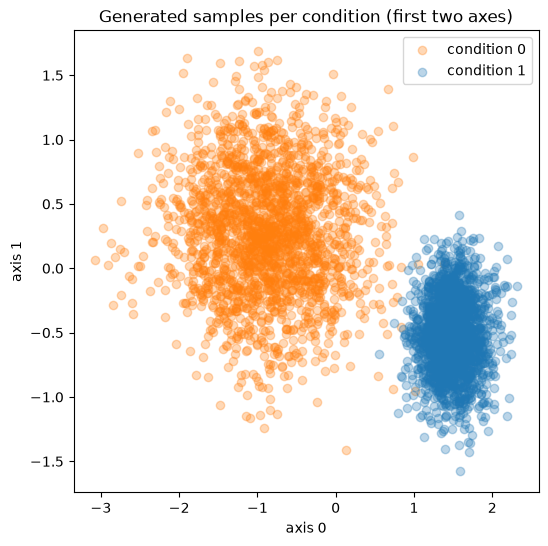

In [ ]:
#Generates random points, and usees the models 
#trained values to predict where those points should land
#Plot shows that most similar points are clustered 
#together, showing good accuracy

n_samples = 2000
n_steps = 100
ts = torch.linspace(0, 1, n_steps + 1)

def sample_condition(condition_value, n_samples):
    x_t = torch.randn(n_samples, dDim, device=DEVICE)
    cond = torch.full((n_samples, 1), float(condition_value), device=DEVICE)
    with torch.inference_mode():
        model.eval()
        for i in range(n_steps):
            t = ts[i].expand(n_samples, 1).to(DEVICE)
            dt = ts[i + 1] - ts[i]
            x_t = x_t + model(t=t, x_t=x_t, condition=cond) * dt
    return x_t.cpu().numpy()

samples_0 = sample_condition(0, n_samples)
samples_1 = sample_condition(1, n_samples)

print("condition 0 -- true mean:", mixture_mus[0], " true std:", mixture_sigmas[0])
print("condition 0 -- generated mean:", samples_0.mean(axis=0), " generated std:", samples_0.std(axis=0))
print("condition 1 -- true mean:", mixture_mus[1], " true std:", mixture_sigmas[1])
print("condition 1 -- generated mean:", samples_1.mean(axis=0), " generated std:", samples_1.std(axis=0))

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
ax.scatter(samples_0[:, 0], samples_0[:, 1], alpha=0.3, label="condition 0", color="tab:orange")
ax.scatter(samples_1[:, 0], samples_1[:, 1], alpha=0.3, label="condition 1", color="tab:blue")
ax.set_xlabel("axis 0")
ax.set_ylabel("axis 1")
ax.set_title("Generated samples per condition (first two axes)")
ax.legend()
display_figure(fig, altText="Scatter plot of generated 3D samples, projected onto the first two axes, colored by condition.")